In [1]:
!pip install timm -q

import os
import torch
import timm
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import f1_score, classification_report

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = "/kaggle/input/datasets/venkatsaikondra/venkat-kondra/Final_Data"
print("Using device:", device)

Using device: cuda


In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2,0.2),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [4]:
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_transform)
test_dataset  = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)

class_names = train_dataset.classes
print("Classes:", class_names)

# 🔥 Handle imbalance
targets = [label for _, label in train_dataset]
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in targets]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

Classes: ['Covid-19', 'Normal', 'Pneumonia-Bacterial', 'Pneumonia-Viral']


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [6]:
model_eff = timm.create_model('tf_efficientnet_b4', pretrained=True, num_classes=4).to(device)
model_inc = timm.create_model('inception_v3', pretrained=True, num_classes=4).to(device)

model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

In [7]:
weights = torch.tensor([1.0, 1.0, 1.2, 1.2]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer_eff = optim.AdamW(model_eff.parameters(), lr=3e-4)
optimizer_inc = optim.AdamW(model_inc.parameters(), lr=3e-4)

scheduler_eff = optim.lr_scheduler.CosineAnnealingLR(optimizer_eff, T_max=30)
scheduler_inc = optim.lr_scheduler.CosineAnnealingLR(optimizer_inc, T_max=30)

In [8]:
def train_effnet(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_eff.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer_eff.zero_grad()
            outputs = model_eff(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_eff.step()

        scheduler_eff.step()

        # VALIDATION
        model_eff.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)

                out = model_eff(images)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"EffNet Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_eff.state_dict(), "best_eff.pth")

    print("✅ EfficientNet Done")

train_effnet()

EffNet Epoch 1 | F1: 0.8590
EffNet Epoch 2 | F1: 0.8299
EffNet Epoch 3 | F1: 0.8868
EffNet Epoch 4 | F1: 0.9030
EffNet Epoch 5 | F1: 0.9055
EffNet Epoch 6 | F1: 0.8950
EffNet Epoch 7 | F1: 0.9002
EffNet Epoch 8 | F1: 0.8676
EffNet Epoch 9 | F1: 0.9121
EffNet Epoch 10 | F1: 0.9229
EffNet Epoch 11 | F1: 0.9335
EffNet Epoch 12 | F1: 0.9357
EffNet Epoch 13 | F1: 0.9346
EffNet Epoch 15 | F1: 0.9347
EffNet Epoch 16 | F1: 0.9449
EffNet Epoch 17 | F1: 0.9417
EffNet Epoch 18 | F1: 0.9433
EffNet Epoch 19 | F1: 0.9477
EffNet Epoch 20 | F1: 0.9522
EffNet Epoch 21 | F1: 0.9478
EffNet Epoch 22 | F1: 0.9543
EffNet Epoch 23 | F1: 0.9468
EffNet Epoch 24 | F1: 0.9529
EffNet Epoch 25 | F1: 0.9591
EffNet Epoch 26 | F1: 0.9511
EffNet Epoch 27 | F1: 0.9523
EffNet Epoch 28 | F1: 0.9503
EffNet Epoch 29 | F1: 0.9559
EffNet Epoch 30 | F1: 0.9528
✅ EfficientNet Done


In [10]:
def train_inception(epochs=30):
    best_f1 = 0

    for epoch in range(epochs):
        model_inc.train()

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # 🔥 resize ONLY here
            images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

            optimizer_inc.zero_grad()
            outputs = model_inc(images_299)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer_inc.step()

        scheduler_inc.step()

        # VALIDATION
        model_inc.eval()
        preds, gts = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                images_299 = F.interpolate(images, size=(299,299), mode='bilinear')

                out = model_inc(images_299)
                pred = torch.argmax(out, dim=1)

                preds.extend(pred.cpu().numpy())
                gts.extend(labels.numpy())

        f1 = f1_score(gts, preds, average='macro')
        print(f"Inception Epoch {epoch+1} | F1: {f1:.4f}")

        if f1 > best_f1:
            best_f1 = f1
            torch.save(model_inc.state_dict(), "best_inc.pth")

    print("✅ Inception Done")

train_inception()

Inception Epoch 1 | F1: 0.8907
Inception Epoch 2 | F1: 0.8982
Inception Epoch 3 | F1: 0.8888
Inception Epoch 4 | F1: 0.8895
Inception Epoch 5 | F1: 0.9117
Inception Epoch 6 | F1: 0.9179
Inception Epoch 7 | F1: 0.9111
Inception Epoch 8 | F1: 0.9031
Inception Epoch 9 | F1: 0.9310
Inception Epoch 10 | F1: 0.9327
Inception Epoch 11 | F1: 0.9221
Inception Epoch 12 | F1: 0.9312
Inception Epoch 13 | F1: 0.9338
Inception Epoch 14 | F1: 0.9423
Inception Epoch 15 | F1: 0.9287
Inception Epoch 16 | F1: 0.9376
Inception Epoch 17 | F1: 0.9424
Inception Epoch 18 | F1: 0.9389
Inception Epoch 19 | F1: 0.9491
Inception Epoch 20 | F1: 0.9475
Inception Epoch 21 | F1: 0.9510
Inception Epoch 22 | F1: 0.9511
Inception Epoch 23 | F1: 0.9511
Inception Epoch 24 | F1: 0.9504
Inception Epoch 25 | F1: 0.9492
Inception Epoch 26 | F1: 0.9529
Inception Epoch 27 | F1: 0.9517
Inception Epoch 28 | F1: 0.9548
Inception Epoch 29 | F1: 0.9453
Inception Epoch 30 | F1: 0.9403
✅ Inception Done


In [11]:
model_eff.load_state_dict(torch.load("best_eff.pth", map_location=device))
model_inc.load_state_dict(torch.load("best_inc.pth", map_location=device))

model_eff.eval()
model_inc.eval()

InceptionV3(
  (Conv2d_1a_3x3): ConvNormAct(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2a_3x3): ConvNormAct(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Conv2d_2b_3x3): ConvNormAct(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNormAct2d(
      64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): ReLU(inplace=True)
    )
  )
  (Pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): ConvNormAct(
    (conv): Conv2d(64, 80, kernel_size

In [12]:
def ensemble_predict(images):

    img224 = images
    img299 = F.interpolate(images, size=(299,299), mode='bilinear')

    out1 = torch.softmax(model_eff(img224), dim=1)
    out2 = torch.softmax(model_inc(img299), dim=1)

    # 🔥 weighted fusion
    out = 0.55 * out1 + 0.45 * out2

    # 🔥 class boost
    boost = torch.tensor([1.0, 1.0, 1.2, 1.2]).to(device)
    out = out * boost

    return out

In [13]:
def tta(images):
    outputs = []

    for t in [
        lambda x: x,
        lambda x: torch.flip(x, dims=[3]),
        lambda x: torch.flip(x, dims=[2]),
    ]:
        aug = t(images)
        outputs.append(ensemble_predict(aug))

    return torch.mean(torch.stack(outputs), dim=0)

In [14]:
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = tta(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print("🔥 FINAL F1:", f1_score(all_labels, all_preds, average='macro'))
print(classification_report(all_labels, all_preds, target_names=class_names))

🔥 FINAL F1: 0.9555950892770071
                     precision    recall  f1-score   support

           Covid-19       0.99      1.00      1.00       405
             Normal       0.99      0.98      0.99       405
Pneumonia-Bacterial       0.93      0.91      0.92       405
    Pneumonia-Viral       0.91      0.93      0.92       405

           accuracy                           0.96      1620
          macro avg       0.96      0.96      0.96      1620
       weighted avg       0.96      0.96      0.96      1620



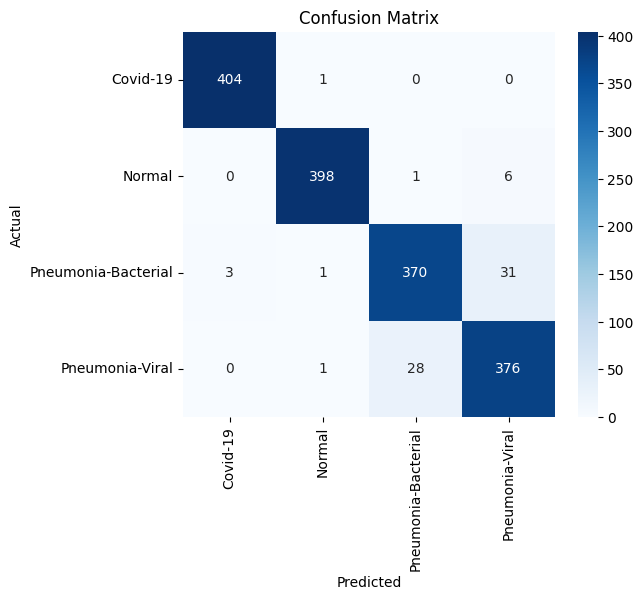

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [17]:

!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 54.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=253ac3e5b0b67e1e25b7d3a3c47729aa1b09d316746852c312448c81002817a9
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [18]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import cv2

In [25]:
import torch
import numpy as np

all_probs = []
all_preds = []
all_labels = []

model_eff.eval()
model_inc.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = tta(images)   # your ensemble + TTA function

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [28]:
def generate_gradcam(image_tensor):

    cam = GradCAM(model=model_eff, target_layers=target_layers)

    input_tensor = F.interpolate(image_tensor, size=(224,224))

    targets = None  # predicted class

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0]

    # Convert image
    img = input_tensor[0].cpu().permute(1,2,0).numpy()
    img = (img - img.min()) / (img.max() - img.min())

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    return visualization

In [31]:
target_layers = [model_eff.conv_head]  

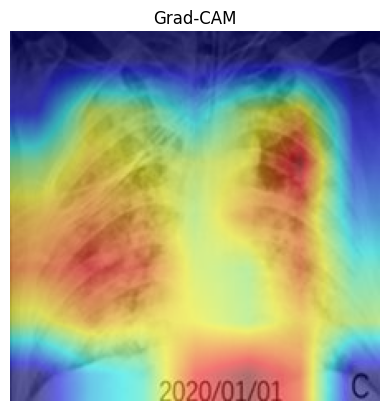

In [32]:
import matplotlib.pyplot as plt

for images, labels in test_loader:
    images = images.to(device)

    cam_img = generate_gradcam(images)

    plt.imshow(cam_img)
    plt.title("Grad-CAM")
    plt.axis('off')
    break

In [38]:
def generate_masks(N=1000, s=8, p1=0.5):
    masks = []
    for _ in range(N):
        mask = np.random.choice([0,1], size=(s,s), p=[1-p1, p1])
        mask = cv2.resize(mask.astype(np.float32), (224,224))
        masks.append(mask)
    return np.array(masks)

In [43]:
def rise_explain(image):

    model_eff.eval()

    img = F.interpolate(image, size=(224,224))
    masks = generate_masks(500)

    preds = []
    for mask in masks:
        mask_tensor = torch.tensor(mask).unsqueeze(0).unsqueeze(0).to(device)
        masked_img = img * mask_tensor

        out = torch.softmax(model_eff(masked_img), dim=1)
        preds.append(out.detach().cpu().numpy())

    preds = np.array(preds)
    saliency = np.mean(masks * preds[:,0,0][:,None,None], axis=0)

    return saliency

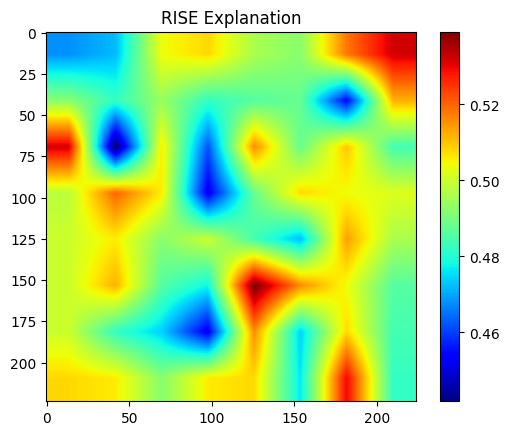

In [44]:
for images, _ in test_loader:
    images = images.to(device)

    saliency = rise_explain(images)

    plt.imshow(saliency, cmap='jet')
    plt.title("RISE Explanation")
    plt.colorbar()
    break

In [46]:
def visualize_features(model, image):

    features = []

    def hook_fn(module, input, output):
        features.append(output)

    handle = model_eff.conv_head.register_forward_hook(hook_fn)

    _ = model_eff(F.interpolate(image, (224,224)))

    handle.remove()

    feat_map = features[0][0].cpu()

    # show first 6 feature maps
    plt.figure(figsize=(10,5))
    for i in range(6):
        plt.subplot(2,3,i+1)
        plt.imshow(feat_map[i].detach().numpy(), cmap='viridis')
        plt.axis('off')
    plt.suptitle("Feature Maps")
    plt.show()

In [48]:
def visualize_ensemble_attention(images):

    img224 = F.interpolate(images, (224,224))
    img299 = F.interpolate(images, (299,299))

    out1 = torch.softmax(model_eff(img224), dim=1)
    out2 = torch.softmax(model_inc(img299), dim=1)

    print("EfficientNet Confidence:", out1)
    print("Inception Confidence:", out2)

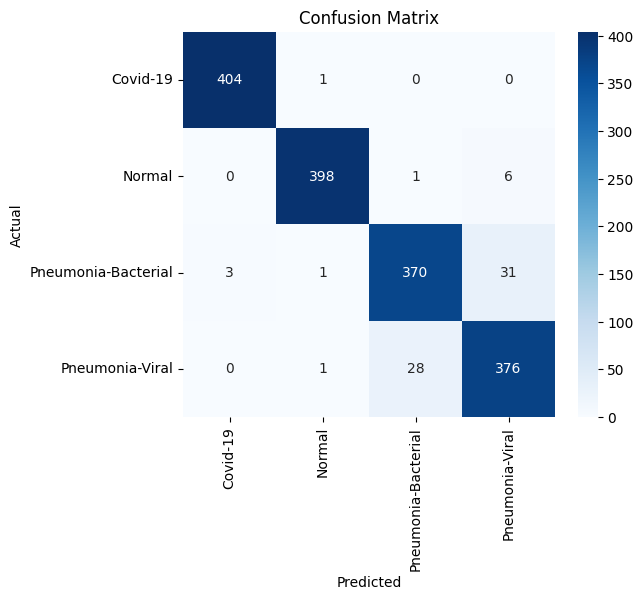

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [50]:
from sklearn.preprocessing import label_binarize

num_classes = len(class_names)

y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))

In [51]:
from sklearn.metrics import roc_curve, auc

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

In [52]:
# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(
    y_true_bin.ravel(), all_probs.ravel()
)
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))

mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= num_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

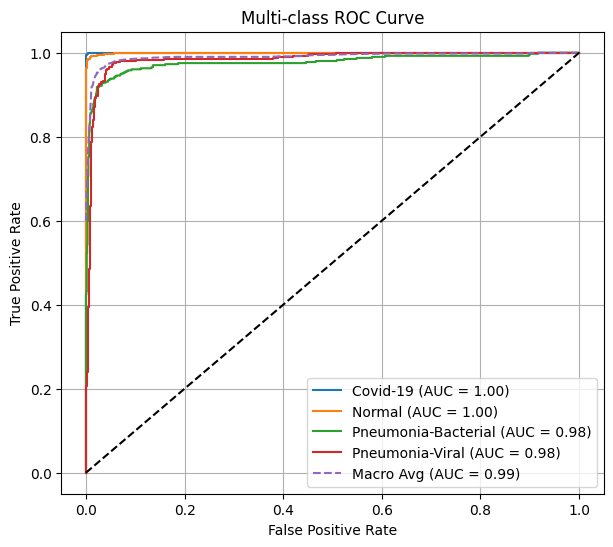

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot(fpr["macro"], tpr["macro"],
         linestyle='--',
         label=f"Macro Avg (AUC = {roc_auc['macro']:.2f})")

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-class ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [54]:
from sklearn.metrics import roc_auc_score

auc_macro = roc_auc_score(y_true_bin, all_probs, average="macro", multi_class="ovr")
auc_weighted = roc_auc_score(y_true_bin, all_probs, average="weighted", multi_class="ovr")

print("Macro AUC:", auc_macro)
print("Weighted AUC:", auc_weighted)

Macro AUC: 0.9900718894477467
Weighted AUC: 0.9900718894477468
